In [29]:
import pandas as pd
from datasets import load_dataset
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import transformers
from transformers import pipeline
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation 

In [2]:
dataset = load_dataset('ag_news', split='train[:100]')

In [3]:
df = pd.DataFrame(dataset)
df[:10]

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2
7,Fed minutes show dissent over inflation (USATO...,2
8,Safety Net (Forbes.com) Forbes.com - After ear...,2
9,Wall St. Bears Claw Back Into the Black NEW Y...,2


In [4]:
df["no_punkt_lower"] = df["text"].apply(lambda x: re.sub(r'[^a-zA-Z\s]', "", x.lower()))
df["no_punkt_lower"]

0     wall st bears claw back into the black reuters...
1     carlyle looks toward commercial aerospace reut...
2     oil and economy cloud stocks outlook reuters r...
3     iraq halts oil exports from main southern pipe...
4     oil prices soar to alltime record posing new m...
                            ...                        
95    gene blocker turns monkeys into workaholics  s...
96    dolphins too have born socialites reuters reut...
97    whats in a name well matt is sexier than paul ...
98    uk scientists allowed to clone human embryos r...
99    russian alien spaceship claims raise eyebrows ...
Name: no_punkt_lower, Length: 100, dtype: object

In [5]:
df["token"] = df["no_punkt_lower"].apply(lambda x: [word for word in word_tokenize(x)])
df["token"]

0     [wall, st, bears, claw, back, into, the, black...
1     [carlyle, looks, toward, commercial, aerospace...
2     [oil, and, economy, cloud, stocks, outlook, re...
3     [iraq, halts, oil, exports, from, main, southe...
4     [oil, prices, soar, to, alltime, record, posin...
                            ...                        
95    [gene, blocker, turns, monkeys, into, workahol...
96    [dolphins, too, have, born, socialites, reuter...
97    [whats, in, a, name, well, matt, is, sexier, t...
98    [uk, scientists, allowed, to, clone, human, em...
99    [russian, alien, spaceship, claims, raise, eye...
Name: token, Length: 100, dtype: object

In [6]:
en_stopwords = stopwords.words('english')

In [7]:
df['token_clean'] = df["token"].apply(lambda x: [word for word in x if word not in en_stopwords])
df['token_clean']

0     [wall, st, bears, claw, back, black, reuters, ...
1     [carlyle, looks, toward, commercial, aerospace...
2     [oil, economy, cloud, stocks, outlook, reuters...
3     [iraq, halts, oil, exports, main, southern, pi...
4     [oil, prices, soar, alltime, record, posing, n...
                            ...                        
95    [gene, blocker, turns, monkeys, workaholics, s...
96    [dolphins, born, socialites, reuters, reuters,...
97    [whats, name, well, matt, sexier, paul, reuter...
98    [uk, scientists, allowed, clone, human, embryo...
99    [russian, alien, spaceship, claims, raise, eye...
Name: token_clean, Length: 100, dtype: object

In [8]:
lematizer = WordNetLemmatizer()

In [9]:
df['lematize_token'] = df["token_clean"].apply(lambda x: [lematizer.lemmatize(word) for word in x ])
df['lematize_token']

0     [wall, st, bear, claw, back, black, reuters, r...
1     [carlyle, look, toward, commercial, aerospace,...
2     [oil, economy, cloud, stock, outlook, reuters,...
3     [iraq, halt, oil, export, main, southern, pipe...
4     [oil, price, soar, alltime, record, posing, ne...
                            ...                        
95    [gene, blocker, turn, monkey, workaholic, stud...
96    [dolphin, born, socialite, reuters, reuters, p...
97    [whats, name, well, matt, sexier, paul, reuter...
98    [uk, scientist, allowed, clone, human, embryo,...
99    [russian, alien, spaceship, claim, raise, eyeb...
Name: lematize_token, Length: 100, dtype: object

In [10]:
df['text_clean'] = df['lematize_token'].apply( lambda x : " ".join(x))
df['text_clean']

0     wall st bear claw back black reuters reuters s...
1     carlyle look toward commercial aerospace reute...
2     oil economy cloud stock outlook reuters reuter...
3     iraq halt oil export main southern pipeline re...
4     oil price soar alltime record posing new menac...
                            ...                        
95    gene blocker turn monkey workaholic study reut...
96    dolphin born socialite reuters reuters people ...
97    whats name well matt sexier paul reuters reute...
98    uk scientist allowed clone human embryo reuter...
99    russian alien spaceship claim raise eyebrow sk...
Name: text_clean, Length: 100, dtype: object

In [11]:
vader_sentiment = SentimentIntensityAnalyzer()

In [12]:
df["vader_sentance_score"] = df['text_clean'].apply(lambda review: vader_sentiment.polarity_scores(review)['compound'])
df["vader_sentance_score"]

0     0.0000
1     0.4404
2    -0.5719
3    -0.0772
4    -0.8271
       ...  
95   -0.4404
96    0.4019
97    0.6249
98    0.2500
99    0.0772
Name: vader_sentance_score, Length: 100, dtype: float64

In [13]:
bins = [-1, -0.1, 0.1, 1]
names = ['negative', 'neutral', 'positive']

In [14]:
df['vader_sentance_label'] = pd.cut(df['vader_sentance_score'], bins, labels=names)

<Axes: xlabel='vader_sentance_label'>

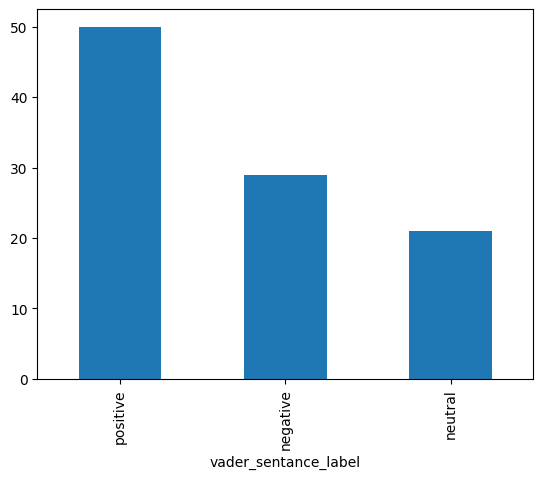

In [15]:
df['vader_sentance_label'].value_counts().plot.bar()

In [16]:
transformer_pipeline = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use mps:0


In [20]:
transformer_labels =[]
for review in df['text_clean'].values:
    sentiment_list = transformer_pipeline(review)
    setiment_label = [sent['label'] for sent in sentiment_list]
    transformer_labels.append(setiment_label)
df["transformer_sentiment_label"] = transformer_labels   

<Axes: xlabel='transformer_sentiment_label'>

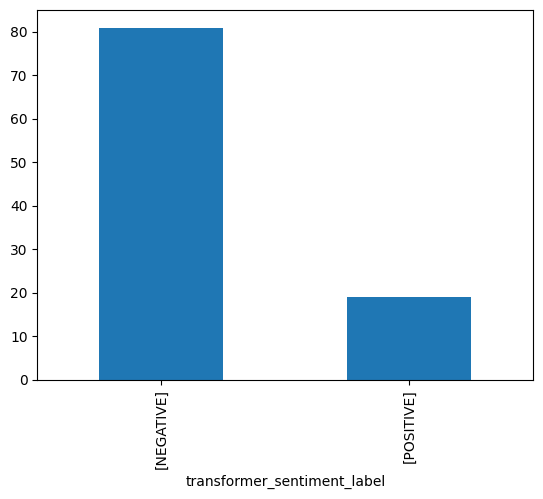

In [21]:
df["transformer_sentiment_label"].value_counts().plot.bar()

In [22]:
df.head()

,text,label,no_punkt_lower,token,token_clean,lematize_token,text_clean,vader_sentance_score,vader_sentance_label,transformer_sentiment_label
0,Wall St. Bears Claw Back Into the Black (Reute...,2,wall st bears claw back into the black reuters...,"[wall, st, bears, claw, back, into, the, black...","[wall, st, bears, claw, back, black, reuters, ...","[wall, st, bear, claw, back, black, reuters, r...",wall st bear claw back black reuters reuters s...,0.0000,neutral,[NEGATIVE]
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,carlyle looks toward commercial aerospace reut...,"[carlyle, looks, toward, commercial, aerospace...","[carlyle, looks, toward, commercial, aerospace...","[carlyle, look, toward, commercial, aerospace,...",carlyle look toward commercial aerospace reute...,0.4404,positive,[NEGATIVE]
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,oil and economy cloud stocks outlook reuters r...,"[oil, and, economy, cloud, stocks, outlook, re...","[oil, economy, cloud, stocks, outlook, reuters...","[oil, economy, cloud, stock, outlook, reuters,...",oil economy cloud stock outlook reuters reuter...,-0.5719,negative,[NEGATIVE]
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,iraq halts oil exports from main southern pipe...,"[iraq, halts, oil, exports, from, main, southe...","[iraq, halts, oil, exports, main, southern, pi...","[iraq, halt, oil, export, main, southern, pipe...",iraq halt oil export main southern pipeline re...,-0.0772,neutral,[NEGATIVE]
4,"Oil prices soar to all-time record, posing new...",2,oil prices soar to alltime record posing new m...,"[oil, prices, soar, to, alltime, record, posin...","[oil, prices, soar, alltime, record, posing, n...","[oil, price, soar, alltime, record, posing, ne...",oil price soar alltime record posing new menac...,-0.8271,negative,[NEGATIVE]


In [23]:
coutvec = CountVectorizer()

In [25]:
countvec_fit = coutvec.fit_transform(df['text_clean'])

In [26]:
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns=coutvec.get_feature_names_out())

In [27]:
bag_of_words

,ability,absenteeism,abuser,accessory,accident,accomplishment,according,across,act,action,...,world,worriesabout,worry,would,wrests,wrong,year,yesterday,york,yusgiantoro
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
98,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
lda_model = LatentDirichletAllocation()

In [31]:
lda_fit = lda_model.fit_transform(bag_of_words)

In [33]:
feature_names = coutvec.get_feature_names_out()

In [34]:
feature_names

array(['ability', 'absenteeism', 'abuser', ..., 'yesterday', 'york',
       'yusgiantoro'], dtype=object)

In [35]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Тема {topic_idx + 1}:")
        
        top_words_idx = topic.argsort()[:-no_top_words - 1:-1]
        
        top_words = [feature_names[i] for i in top_words_idx]
        print(" ".join(top_words))
        

In [36]:
display_topics(lda_model, feature_names, 10)

Тема 1:
reuters oil said market fund ap year latest opec week
Тема 2:
company five june sale technology japan usatodaycom allegedly slows superpower
Тема 3:
new lynn square grant york central may fall economy alligator
Тема 4:
reuters new best project autodesk one said group city asian
Тема 5:
email company world researcher apple ibm beat pc reuters football
Тема 6:
customer company need blue new project sapient today firm world
Тема 7:
ap russian space said claim growth time bank researcher technology
Тема 8:
google reuters company ipo go car interview offering auction nuclear
Тема 9:
reuters stock oil outlook economy price new market dell share
Тема 10:
wall reuters bn market street phone barrel philippine get election
